## Denoising Diffusion Probabilistic Models

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import math
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
from abc import ABC, abstractmethod
import time

torch.manual_seed(0)
np.random.seed(0)

![DDPM Train algorithm](/home/jwade19/Desktop/ME595R_DL/ME595R_DeepLearning/DL_testing/ddpm/algorithm_ddpm_train.png)

![DDPM Sample algorithm](/home/jwade19/Desktop/ME595R_DL/ME595R_DeepLearning/DL_testing/ddpm/algorithm_ddpm_sample.png)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEBUG = False
print(f"Using device: {device}")

Using device: cuda


In [4]:
transform = transforms.Compose([
    transforms.Pad(2),                             # 28x28 → 32x32
    transforms.ToTensor(),                        # [0, 255] → [0.0, 1.0]
    transforms.Normalize((0.5,), (0.5,))          # [0, 1] → [-1, 1]
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

n_samples = len(train_dataset)
indices = torch.randperm(len(train_dataset))[:n_samples]
train_subset = Subset(train_dataset, indices)

train_loader = DataLoader(
    train_subset,
    batch_size=64,
    shuffle=True,
    num_workers=0 if DEBUG else 4,
    pin_memory=True
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0 if DEBUG else 4,
    pin_memory=True
)

def show_images(imgs, nrow=8):
    imgs = (imgs + 1) / 2
    imgs = imgs.clamp(0, 1)
    grid = torchvision.utils.make_grid(imgs, nrow=nrow)
    grid = grid.permute(1, 2, 0).cpu().numpy()
    plt.figure(figsize=(12, 12))
    plt.imshow(grid, cmap='gray')
    plt.axis('off')
    plt.show()

In [5]:
class NoiseScheduler(ABC):
    def __init__(self, num_steps, device, beta_start=0.0001, beta_end=0.02):
        self.num_steps = num_steps
        self.device = device
        self.beta_start = beta_start
        self.beta_end = beta_end

    @abstractmethod
    def calc_betas(self, **kwargs):
        pass

    def calc_other_values(self, betas):
        self.alphas = 1.0 - betas
        self.alpha_cumprod = torch.cumprod(self.alphas, dim=0).to(device)
        self.sqrt_alpha_cumprod = torch.sqrt(self.alpha_cumprod).to(device)
        self.sqrt_one_minus_alpha_cumprod = torch.sqrt(1 - self.alpha_cumprod).to(device)

    def add_noise(self, original, noise, t):
        return self.sqrt_alpha_cumprod[t][:, None, None, None] * original + \
            self.sqrt_one_minus_alpha_cumprod[t][:, None, None, None] * noise

    def sample_prev_timestep(self, xt, noise_pred, t):
        # t is now a plain python int
        sqrt_alpha_cumprod_t = self.sqrt_alpha_cumprod[t]
        sqrt_one_minus_alpha_cumprod_t = self.sqrt_one_minus_alpha_cumprod[t]

        x0 = (xt - sqrt_one_minus_alpha_cumprod_t * noise_pred) / sqrt_alpha_cumprod_t
        x0 = torch.clamp(x0, -1, 1)

        if t == 0:
            return x0, x0

        alpha_cumprod_t = self.alpha_cumprod[t]
        alpha_cumprod_prev = self.alpha_cumprod[t-1]
        beta_t = self.betas[t]
        alpha_t = self.alphas[t]

        mean = (torch.sqrt(alpha_cumprod_prev) * beta_t / (1 - alpha_cumprod_t)) * x0 \
            + (torch.sqrt(alpha_t) * (1 - alpha_cumprod_prev) / (1 - alpha_cumprod_t)) * xt

        variance = (1 - alpha_cumprod_prev) / (1 - alpha_cumprod_t) * beta_t
        noise = torch.randn_like(xt)
        return mean + torch.sqrt(variance) * noise, x0

class LinearNoiseScheduler(NoiseScheduler):
    def __init__(self, num_steps, device, beta_start=0.0001, beta_end=0.02):
        super().__init__(num_steps, device, beta_start, beta_end)
        self.betas = self.calc_betas(beta_start, beta_end, num_steps)
        self.calc_other_values(self.betas)

    def calc_betas(self, beta_start, beta_end, num_steps):
        return torch.linspace(beta_start, beta_end, num_steps).to(device)

class CosineNoiseScheduler(NoiseScheduler):
    def __init__(self, num_steps, device, beta_start=0.0001, beta_end=0.02):
        super().__init__(num_steps, device, beta_start, beta_end)
        self.betas = self.calc_betas(num_steps)
        self.calc_other_values(self.betas)

    def calc_betas(self, num_steps):
        t = torch.arange(0, num_steps+1, device=self.device)
        s = 0.008
        f = torch.cos((t/num_steps + s)/(1+s)*torch.pi/2)**2
        alphabar_t = f/f[0]
        betas = 1 - alphabar_t[1:]/alphabar_t[:-1]
        betas = torch.clip(betas, 1e-8, 0.999)
        return betas

[Attention is all you need](https://arxiv.org/pdf/1706.03762)

![time encoding](time_encoding.png)

In [6]:
def get_time_embedding(time_steps: torch.Tensor, t_emb_dim, max_period = 10000):
    # We want the rows of the time embedding to be a new time. We want the entries in each row to be a time embedding
    d_model = t_emb_dim // 2
    factor = max_period**(torch.arange(0, d_model, device=time_steps.device)/d_model)
    t_emb = time_steps[:, torch.newaxis].repeat(1, d_model) / factor # dimension (n_time_steps x d_model) / (d_model,) Broadcastign then copies factor as a (n_time_steps x d_model) where each row is the same
    t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], axis=-1) # dimension n_time_steps x t_emb_dim
    return t_emb

In [7]:
def zero_module(module):
    for p in module.parameters():
        p.detach().zero_()
    return module

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, t_emb_dim, dropout):
        super().__init__()
        self.resnet_conv_first = nn.Sequential(
            nn.GroupNorm(8, in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        )
        self.t_emb_layers = nn.Sequential(
            nn.SiLU(),
            nn.Linear(t_emb_dim, out_channels)
        )
        self.resnet_conv_second = nn.Sequential(
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Dropout(p=dropout),
            zero_module(nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1))
        )
        self.residual_input_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, t_emb):
        # Resnet block with time embedding
        out = self.resnet_conv_first(x)
        t_emb_out = self.t_emb_layers(t_emb)[:, :, torch.newaxis, torch.newaxis]
        out = out + t_emb_out
        out = self.resnet_conv_second(out)
        out = out + self.residual_input_conv(x)

        return out

class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads):
        super().__init__()
        self.attention_norm = nn.GroupNorm(8, channels)
        self.attention = nn.MultiheadAttention(channels, num_heads, batch_first=True)

    def forward(self, x):
        b, c, h, w = x.shape
        attention_in = self.attention_norm(x).view(b, c, h*w).transpose(1, 2) # b x (h*w) x c
        # queries, keys, values all come from the same place, the output of the resnet block
        attn_out, _ = self.attention(attention_in, attention_in, attention_in)
        attn_out = attn_out.transpose(1, 2).view(b, c, h, w)
        return attn_out

class Downsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.downsample = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        assert x.shape[1] == self.downsample.in_channels, f"Expected input with {self.downsample.in_channels} channels, got {x.shape[1]}"
        return self.downsample(x)

class Upsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        assert x.shape[1] == self.conv.in_channels, f"Expected input with {self.conv.in_channels} channels, got {x.shape[1]}"
        x = self.upsample(x)
        x = self.conv(x)
        return x

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, t_emb_dim, down_sample, num_heads, dropout):
        super().__init__()
        self.down_sample = down_sample
        self.residual_block = ResidualBlock(in_channels, out_channels, t_emb_dim, dropout)
        self.attention_block = AttentionBlock(out_channels, num_heads) if in_channels == 32 else nn.Identity() # only put attention in the middle layer
        self.downsample_layer = Downsample(out_channels, out_channels) if down_sample else nn.Identity()

    def forward(self, x, t_emb):
        out = self.residual_block(x, t_emb)
        attn_out = self.attention_block(out)
        skip = out + attn_out
        out = self.downsample_layer(skip)
        return out, skip

class MidBlock(nn.Module):
    def __init__(self, in_channels, out_channels, t_emb_dim, num_heads, dropout):
        super().__init__()
        self.residual_block1 = ResidualBlock(in_channels, out_channels, t_emb_dim, dropout=dropout)
        self.attention_block = AttentionBlock(out_channels, num_heads)
        self.residual_block2 = ResidualBlock(out_channels, out_channels, t_emb_dim, dropout=dropout)

    def forward(self, x, t_emb):
        out = self.residual_block1(x, t_emb)
        attn_out = self.attention_block(out)
        out = out + attn_out
        out = self.residual_block2(out, t_emb)
        return out

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels, up_sample_channel, t_emb_dim, up_sample, num_heads, dropout):
        super().__init__()
        self.up_sample = up_sample
        self.residual_block = ResidualBlock(in_channels, out_channels, t_emb_dim, dropout)
        self.attention_block = AttentionBlock(out_channels, num_heads) if out_channels == 32 else nn.Identity()
        self.upsample_layer = Upsample(up_sample_channel, up_sample_channel) if up_sample else nn.Identity()

    def forward(self, x, out_down, t_emb):
        x = self.upsample_layer(x)
        x = torch.cat([x, out_down], dim=1) # concatenate along channel dimension
        out = self.residual_block(x, t_emb)
        attn_out = self.attention_block(out)
        out = out + attn_out

        return out

class UNet(nn.Module):
    def __init__(self, im_channels):
        super().__init__()
        self.im_channels = im_channels
        self.down_channels = [32, 64, 128]
        # 1x32x32 -> 32x16x16 -> 64x8x8 --> 128x4x4
        self.mid_channels = [128]
        self.t_emb_dim = 128
        self.p_dropout = 0.1
        self.num_heads = 4
        self.down_sample = [True, True, True]
        self.t_emb_initial_size = self.t_emb_dim // 4

        self.t_projection = nn.Sequential(
            nn.Linear(self.t_emb_initial_size, self.t_emb_dim),
            nn.SiLU(),
            nn.Linear(self.t_emb_dim, self.t_emb_dim)
        )

        self.initial_img_project = zero_module(nn.Conv2d(im_channels, self.down_channels[0], kernel_size=3, stride=1, padding=1))

        self.down_blocks = nn.ModuleList()
        for i in range(len(self.down_channels)):
            in_channels = self.initial_img_project.out_channels if i == 0 else self.down_channels[i-1]
            out_channels = self.down_channels[i]
            down_sample = self.down_sample[i]
            self.down_blocks.append(DownBlock(in_channels, out_channels, self.t_emb_dim, down_sample, self.num_heads, self.p_dropout))

        self.mid_block = MidBlock(self.down_channels[-1], self.mid_channels[0], self.t_emb_dim, self.num_heads, self.p_dropout)

        self.up_blocks = nn.ModuleList()
        for i in range(len(self.down_channels)-1, -1, -1):
            in_channels = self.down_channels[i] + self.mid_channels[-1] if i == len(self.down_channels) - 1 else self.down_channels[i] + self.down_channels[i]
            out_channels = self.down_channels[0] if i == 0 else self.down_channels[i-1]
            up_sample = self.down_sample[i]
            up_sample_channel = self.mid_channels[-1] if i == len(self.down_channels) - 1 else self.down_channels[i]
            self.up_blocks.append(UpBlock(in_channels, out_channels, up_sample_channel, self.t_emb_dim, up_sample, self.num_heads, self.p_dropout))

        self.final_conv = nn.Sequential(
            nn.GroupNorm(8, self.down_channels[0]),
            nn.SiLU(),
            zero_module(nn.Conv2d(self.down_channels[0], im_channels, kernel_size=3, stride=1, padding=1))
        )

    def forward(self, x, time_steps, max_time_steps):
        t_emb = get_time_embedding(time_steps, self.t_emb_initial_size, max_period=max_time_steps)
        t_emb = self.t_projection(t_emb)

        x = self.initial_img_project(x)

        skip_connections = []
        for down_block in self.down_blocks:
            x, skip = down_block(x, t_emb)
            skip_connections.append(skip)

        x = self.mid_block(x, t_emb)

        for up_block in self.up_blocks:
            skip = skip_connections.pop()
            x = up_block(x, skip, t_emb)

        out = self.final_conv(x)
        return out

In [27]:
def train(model, train_dataloader, noise_scheduler, optimizer, device):
    model.train()
    total_loss = 0
    for x, _ in train_dataloader:
        x0 = x.to(device)
        b, c, h, w = x0.shape
        t = torch.randint(0, noise_scheduler.num_steps, (b,), device=device).long()
        noise = torch.randn_like(x0).to(device)
        xt = noise_scheduler.add_noise(x0, noise, t)

        noise_pred = model(xt, t, noise_scheduler.num_steps)

        loss = F.mse_loss(noise_pred, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * b

    return total_loss / len(train_dataloader.dataset)

def train_epochs(model, train_dataloader, noise_scheduler, optimizer, device, num_epochs):
    pbar = tqdm(range(num_epochs), desc="Training", leave=True, position=0)
    train_losses = []
    for epoch in pbar:
        loss = train(model, train_dataloader, noise_scheduler, optimizer, device)
        pbar.set_postfix({"loss": loss})
        train_losses.append(loss)
    return train_losses

@torch.no_grad()
def sample(
    model,
    noise_scheduler,
    device,
    n_samples=16,
    img_size=32,
    img_channels=1,
    movie=False,
    fps=20,
    save_path=None,
    dpi=120,
):
    model.eval()

    xt = torch.randn(n_samples, img_channels, img_size, img_size).to(device)

    if movie:
        frames = [xt.detach().cpu()]
        t_labels = [noise_scheduler.num_steps]

    for t in tqdm(reversed(range(noise_scheduler.num_steps)), desc="Sampling"):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        noise_pred = model(xt, t_batch, noise_scheduler.num_steps)
        xt, x0 = noise_scheduler.sample_prev_timestep(xt, noise_pred, t)

        if movie:
            frames.append(xt.detach().cpu())
            t_labels.append(t)

    if movie:
        from matplotlib import animation
        from IPython.display import HTML, display
        from pathlib import Path

        nrow = max(1, int(np.sqrt(n_samples)))
        grids = []
        for frame in frames:
            imgs = ((frame + 1) / 2).clamp(0, 1)
            grid = torchvision.utils.make_grid(imgs, nrow=nrow)
            grid = grid.permute(1, 2, 0).numpy()
            if grid.shape[-1] == 1:
                grid = grid[:, :, 0]
            grids.append(grid)

        fig, ax = plt.subplots(figsize=(6, 6))
        if np.ndim(grids[0]) == 2:
            im = ax.imshow(grids[0], cmap='gray', vmin=0, vmax=1, animated=True)
        else:
            im = ax.imshow(grids[0], vmin=0, vmax=1, animated=True)
        title = ax.set_title(f"t = {t_labels[0]}")
        ax.axis('off')

        def update(i):
            im.set_array(grids[i])
            title.set_text(f"t = {t_labels[i]}")
            return im, title

        ani = animation.FuncAnimation(
            fig,
            update,
            frames=len(grids),
            interval=1000 / fps,
            blit=True,
            repeat=False,
        )

        if save_path is not None:
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            suffix = save_path.suffix.lower()
            if suffix == ".gif":
                writer = animation.PillowWriter(fps=fps)
                ani.save(save_path.as_posix(), writer=writer, dpi=dpi)
            elif suffix == ".mp4":
                try:
                    writer = animation.FFMpegWriter(fps=fps)
                    ani.save(save_path.as_posix(), writer=writer, dpi=dpi)
                except Exception as e:
                    print(f"Could not save MP4 ({e}). Try GIF or install ffmpeg.")
            else:
                print("Unsupported save_path extension. Use .gif or .mp4")

        plt.close(fig)
        # display(HTML(ani.to_jshtml()))

    return xt

In [11]:
num_epochs = 20
max_time_steps = 1000
model = UNet(im_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
linear = False
if linear:
    noise_scheduler = LinearNoiseScheduler(num_steps=max_time_steps, device=device)
else:
    noise_scheduler = CosineNoiseScheduler(num_steps=max_time_steps, device=device)

In [ ]:
train_losses = train_epochs(model, train_loader, noise_scheduler, optimizer, device, num_epochs)

Training: 100%|██████████| 20/20 [1:34:08<00:00, 282.41s/it, loss=0.0177]


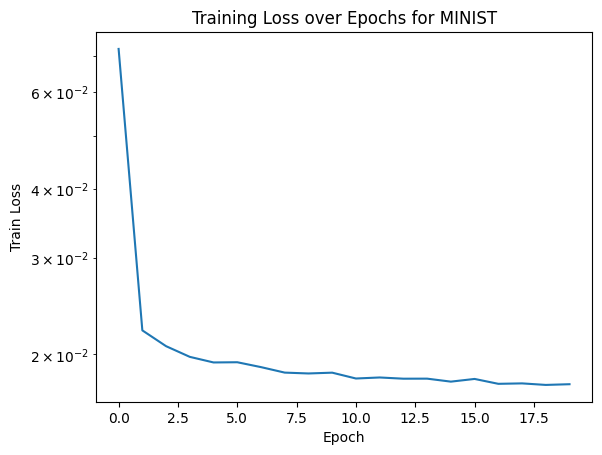

In [ ]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss over Epochs for MINIST")
plt.yscale("log")
plt.savefig(f"{'linear' if linear else 'cosine'}/ddpm_training_loss_{'linear' if linear else 'cosine'}_{time.strftime('%Y-%m-%d_%H-%M-%S')}.png", dpi=200)
plt.show()

In [ ]:
torch.save(model.state_dict(), f"{'linear' if linear else 'cosine'}/ddpm_unet_{'linear' if linear else 'cosine'}_{time.strftime('%Y-%m-%d_%H-%M-%S')}.pth")

In [23]:
model = UNet(im_channels=1).to(device)
model.load_state_dict(torch.load(f"/home/jwade19/Desktop/ME595R_DL/ME595R_DeepLearning/DL_testing/ddpm/cosine/ddpm_unet_cosine_2026-03-27_01-50-20.pth", map_location=device))
xt = sample(model, noise_scheduler, device, n_samples=64, img_size=32, img_channels=1,
            movie=False, fps=50, save_path=f"{'linear' if linear else 'cosine'}/ddpm_sampling_{'linear' if linear else 'cosine'}_{time.strftime('%Y-%m-%d_%H-%M-%S')}.mp4", dpi=200)
show_images(xt, nrow=8)

FileNotFoundError: [Errno 2] No such file or directory: '/home/jwade19/Desktop/ME595R_DL/ME595R_DeepLearning/DL_testing/ddpm/cosine/ddpm_unet_cosine_2026-03-27_01-50-20.pth'

## Figure Generation

Sampling: 1000it [00:03, 271.22it/s]


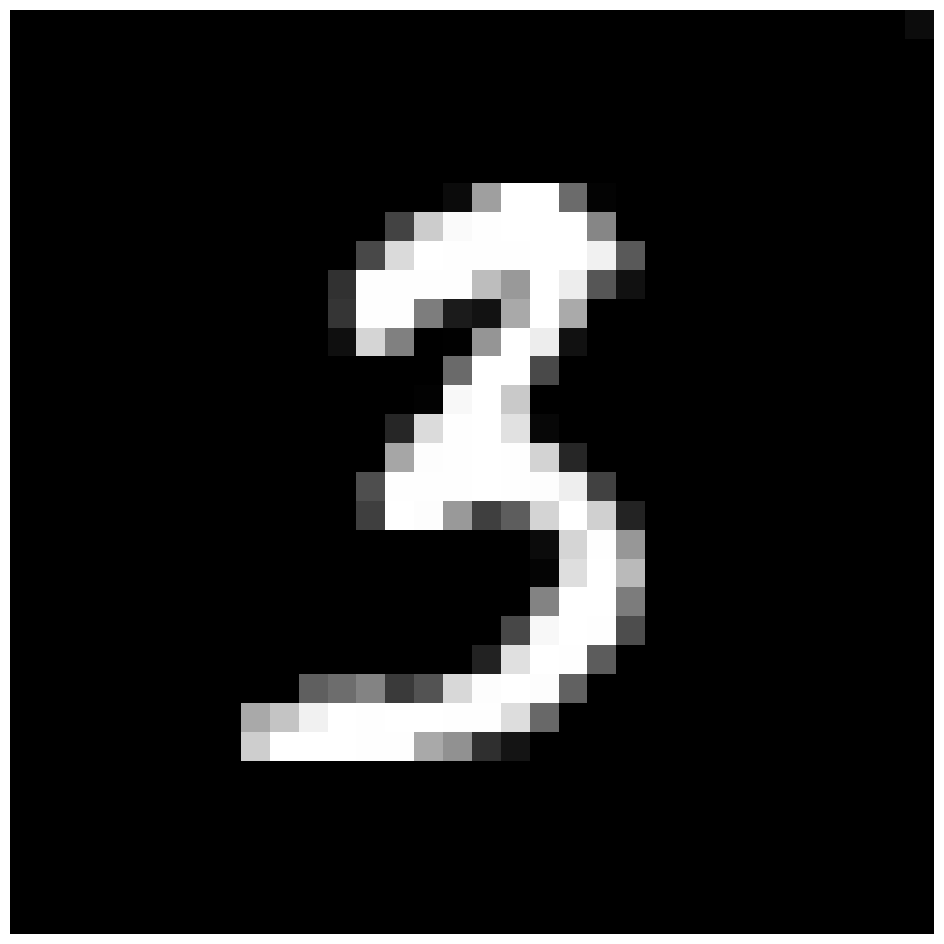

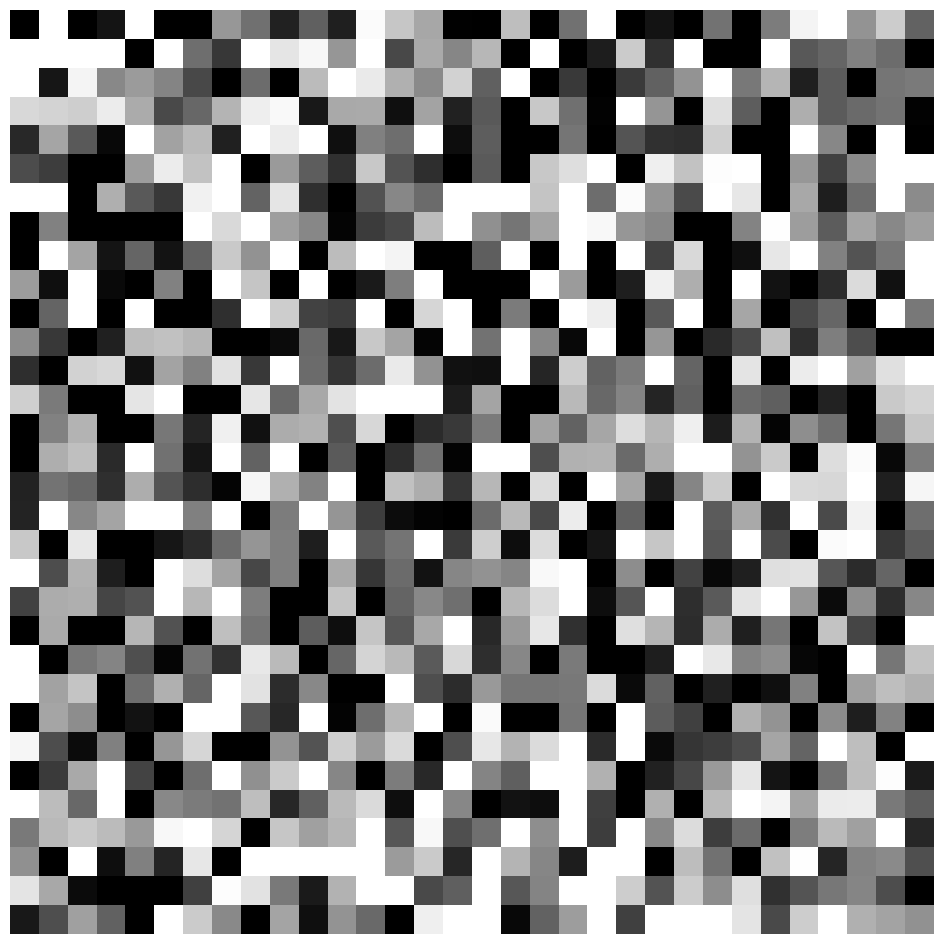

In [28]:
torch.manual_seed(2)
model = UNet(im_channels=1).to(device)
model.load_state_dict(torch.load(f"/home/jwade19/Desktop/ME595R_DL/ME595R_DeepLearning/final_project/ddpm/cosine/ddpm_unet_cosine_2026-03-27_01-50-20.pth", map_location=device))
xt = sample(model, noise_scheduler, device, n_samples=1, img_size=32, img_channels=1,
            movie=False, fps=50, save_path=f"{'linear' if linear else 'cosine'}/ddpm_sampling_{'linear' if linear else 'cosine'}_{time.strftime('%Y-%m-%d_%H-%M-%S')}.mp4", dpi=200)
show_images(xt, nrow=1)
show_images(torch.randn(1,1,32,32), nrow=1)